# Response Latency Analysis - Refactored

This notebook analyzes response onset latencies for forebrain vs hindbrain regions and across brain areas.

**Analysis Steps:**
1. Detect response onset using smoothed derivative method
2. Compare forebrain vs hindbrain latencies (paired)
3. Normalize latencies relative to olfactory bulb
4. Compare all brain areas to olfactory bulb
5. Generate visualizations

In [9]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from scipy.signal import savgol_filter
from scipy.stats import spearmanr

import json

## 1. Configuration and Parameters

In [10]:
# ============================================================================
# FILE PATHS - Modify these for your system
# ============================================================================

# Input files
FOREBRAIN_DATA_PATH = '/Volumes/LaCie/larval_HuC/imaging/7dpf_fb_fish_dfs_final.h5'
HINDBRAIN_DATA_PATH = '/Volumes/LaCie/larval_HuC/imaging/7dpf_hb_fish_dfs_final.h5'

# Output files
OUTPUT_FB_HB_CSV = '/Volumes/LaCie/larval_HuC/imaging/7dpf_fb_hb_latency.csv'
OUTPUT_AREA_CSV = '/Volumes/LaCie/larval_HuC/imaging/7dpf_area_latency_stats.csv'
OUTPUT_FB_HB_PLOT = "/Users/bethanjenkins/Documents/valence_paper_code/FiNA/figures/7dpf_region_response_latencies_scatter.svg"
OUTPUT_AREA_PLOT = "/Users/bethanjenkins/Documents/valence_paper_code/FiNA/figures/7dpf_area_response_latencies_pvalue.svg"

In [11]:
# ============================================================================
# ANALYSIS PARAMETERS
# ============================================================================

# Stimuli to include in analysis
KEY_STIMULI = ['ade', 'cad_2.5mm', 'kw', 'fex_1', 'qui_2.5mm', 'pro_2.5mm', 'ph4.5']

CONCENTRATION_STIMULI = [
    'fex_1','fex_2','fex_3',
    'cad_2.5mM','cad_250um','cad_25um',
    'qui_2.5mM','qui_250um','qui_25um',
    'pro_2.5mM','pro_250um','pro_25um'
]

STIMULUS_LABELS = {
    'fex_1': 'Fex 1:10',
    'fex_2': 'Fex 1:100',
    'fex_3': 'Fex 1:1000',
    'cad_2.5mM': 'Cad 2.5mM',
    'cad_250um': 'Cad 250µM',
    'cad_25um': 'Cad 25µM',
    'qui_2.5mM': 'Qui 2.5mM',
    'qui_250um': 'Qui 250µM',
    'qui_25um': 'Qui 25µM',
    'pro_2.5mM': 'Pro 2.5mM',
    'pro_250um': 'Pro 250µM',
    'pro_25um': 'Pro 25µM',
}

# Fish lists
FOREBRAIN_FISH = ['230713_fb', '230714_fb', '230720_fb', '230727_fb', '230728_fb', 
                  '230810_fb', '230811_fb', '230817_fb', '230818_fb', '230919_fb']
HINDBRAIN_FISH = ['230713_hb', '230714_hb', '230720_hb', '230727_hb', '230728_hb', 
                  '230810_hb', '230811_hb', '230817_hb', '230818_hb', '230919_hb']

# Brain areas for detailed analysis
BRAIN_AREAS = ['olfactory_bulb', 'olfactory_epithelium', 'pallium', 'subpallium', 
               'posterior_tuberculum', 'dorsal_habenula', 'ventral_habenula', 'preoptic', 
               'eminentia_thalami', 'prethalamus', 'rostral_hypothalamus', 'intermediate_hypothalamus']

# Onset detection parameters (EASY TO MODIFY HERE!)
START_FRAME = 159  # Frame after which to search for onset
SMOOTHING_SIGMA = 4  # Gaussian filter sigma for trace smoothing
DERIVATIVE_THRESHOLD = 0.005  # Threshold for derivative to detect onset

# Onset filtering
MIN_VALID_ONSET = 153  # Minimum valid onset frame
MAX_VALID_ONSET = 189  # Maximum valid onset frame

# Time conversion
FRAME_RATE = 3  # Hz (frames per second)
FRAME_TO_SECONDS = 1 / FRAME_RATE  # Conversion factor

# Reference area for normalization
REFERENCE_AREA = 'olfactory_bulb'

# Statistical test parameters
STATISTICAL_TEST_FB_HB = 'two-sided'  # Mann-Whitney U test alternative
STATISTICAL_TEST_AREAS = 'wilcoxon'  # Wilcoxon signed-rank for paired data

In [12]:
# ============================================================================
# AREA NAME MAPPINGS AND ORDER
# ============================================================================

AREA_SHORTHAND_DICT = {
    'olfactory_epithelium': 'OE',
    'olfactory_bulb': 'OB', 
    'pallium': 'Pal', 
    'subpallium': 'SubP',
    'preoptic': 'POA', 
    'prethalamus': 'PTh', 
    'eminentia_thalami': 'EmT', 
    'dorsal_habenula': 'dHb', 
    'ventral_habenula': 'vHb', 
    'posterior_tuberculum': 'PT', 
    'rostral_hypothalamus': 'HR',
    'intermediate_hypothalamus': 'HI'
}

# Define plotting order
AREA_ORDER = list(AREA_SHORTHAND_DICT.keys())

## 2. Import Libraries

In [13]:
import numpy as np 
import matplotlib
import matplotlib.pyplot as plt
import pandas as pd
import os
from pathlib import Path
from skimage import io
import pickle
import json
from ast import literal_eval
from scipy.stats import linregress
from sklearn.cluster import KMeans
from scipy.ndimage import gaussian_filter1d
import scipy.stats as stats
import statsmodels.stats.multitest as multitest
from itertools import combinations
from statsmodels.stats.multitest import multipletests
from scipy.stats import wilcoxon, mannwhitneyu

import warnings
warnings.filterwarnings('ignore')

## 3. Onset Detection Function

Detects response onset using smoothed derivative method.

In [4]:
def detect_onset_smoothed_derivative(trace, start_frame=START_FRAME, 
                                     smoothing_sigma=SMOOTHING_SIGMA, 
                                     derivative_threshold=DERIVATIVE_THRESHOLD):
    """Calculate the smoothed derivative and detect onset after a given frame.
    
    Args:
        trace: 1D array of neural activity over time
        start_frame: Frame after which to search for onset (default from params)
        smoothing_sigma: Sigma for Gaussian smoothing (default from params)
        derivative_threshold: Threshold for derivative detection (default from params)
        
    Returns:
        smoothed_trace: Gaussian-smoothed trace
        derivative: First derivative of smoothed trace
        onset_time: Frame where onset was detected (None if not found)
    """
    # Smooth the signal using a Gaussian filter
    smoothed_trace = gaussian_filter1d(trace, sigma=smoothing_sigma)
    
    # Calculate the first derivative
    derivative = np.diff(smoothed_trace)
    
    # Find the onset time where the derivative exceeds the threshold after the start_frame
    onset_time = None
    for t in range(start_frame, len(derivative)):
        if derivative[t] > derivative_threshold:
            onset_time = t
            break
    
    return smoothed_trace, derivative, onset_time

## 4. Forebrain vs Hindbrain Analysis

Compare response latencies between forebrain and hindbrain regions.

In [20]:
def process_fish(fish, area, file_path, plot_traces=False):
    """Process a single fish to detect response onset.
    
    Args:
        fish: Fish ID string
        area: Brain region ('forebrain' or 'hindbrain')
        file_path: Path to HDF5 data file
        plot_traces: If True, plot smoothed traces and onset (default False)
        
    Returns:
        dict: {'fish_id', 'area', 'onset_time'} or None if no data
    """
    fish_data = pd.read_hdf(file_path, where='fish_id == fish')
    
    # Keep only key stimuli
    stim_data = fish_data[fish_data['stimulus'].isin(KEY_STIMULI)]
    
    # Convert trace strings to arrays
    stim_data['trace'] = stim_data['trace_serialised'].apply(eval)

    if not stim_data.empty:
        # Compute average trace over all stimuli
        avg_trace = np.mean(np.stack(stim_data['trace'].values), axis=0)

        # Detect onset using smoothed derivative method
        smoothed_trace, derivative, onset_time = detect_onset_smoothed_derivative(avg_trace)

        # Optional plotting for debugging/visualization
        if plot_traces:
            plt.figure()
            plt.plot(smoothed_trace[80:], label='Smoothed Trace')
            if onset_time is not None and onset_time >= 80:
                plt.axvline(onset_time - 80, color='g', linestyle='--', label='Onset Time')
            plt.title(f'{fish} {area.capitalize()} - Averaged Across Stimuli')
            plt.xlabel('Frame')
            plt.legend()
            plt.tight_layout()
            plt.show()
        
        return {'fish_id': fish, 'area': area, 'onset_time': onset_time}
    
    return None

def process_fish_by_stimulus(fish, area, file_path, plot_traces=False):
    """Process a single fish to detect response onset for each concentration stimulus.

    Args:
        fish: Fish ID string
        area: Brain region ('forebrain' or 'hindbrain')
        file_path: Path to HDF5 data file
        plot_traces: If True, plot smoothed traces and onset for each stimulus

    Returns:
        list[dict]: Each dict contains {'fish_id','area','stimulus','onset_time'}.
                    Returns an empty list if no valid data found.
    """
    fish_data = pd.read_hdf(file_path, where='fish_id == fish')

    # Keep only concentration stimuli
    stim_data = fish_data[fish_data['stimulus'].isin(CONCENTRATION_STIMULI)].copy()

    if stim_data.empty:
        return []

    # Convert trace strings to arrays (same as process_fish)
    stim_data['trace'] = stim_data['trace_serialised'].apply(eval)

    results = []

    for stim in CONCENTRATION_STIMULI:
        stim_df = stim_data[stim_data['stimulus'] == stim]

        if stim_df.empty:
            continue

        # Average trace over all neurons (and whatever else is in rows) for this stimulus
        avg_trace = np.mean(np.stack(stim_df['trace'].values), axis=0)

        # Detect onset (same as process_fish)
        smoothed_trace, derivative, onset_time = detect_onset_smoothed_derivative(avg_trace)

        if onset_time is None:
            continue

        if plot_traces:
            plt.figure()
            plt.plot(smoothed_trace[80:], label='Smoothed Trace')
            if onset_time is not None and onset_time >= 80:
                plt.axvline(onset_time - 80, color='g', linestyle='--', label='Onset Time')
            plt.title(f'{fish} {area.capitalize()} - {STIMULUS_LABELS.get(stim, stim)}')
            plt.xlabel('Frame')
            plt.legend()
            plt.tight_layout()
            plt.show()

        results.append({
            'fish_id': fish,
            'area': area,
            'stimulus': stim,
            'onset_time': onset_time
        })

    return results

In [7]:
# Initialize list to store onset times
onset_times_list = []

# Process forebrain fish
print("Processing forebrain fish...")
for fish in FOREBRAIN_FISH:
    result = process_fish(fish, 'forebrain', FOREBRAIN_DATA_PATH)
    if result:
        onset_times_list.append(result)

# Process hindbrain fish
print("Processing hindbrain fish...")
for fish in HINDBRAIN_FISH:
    result = process_fish(fish, 'hindbrain', HINDBRAIN_DATA_PATH)
    if result:
        onset_times_list.append(result)

# Convert to DataFrame
region_times_df = pd.DataFrame(onset_times_list)

# Normalize onset times relative to stimulus onset (START_FRAME=159) and convert to seconds
region_times_df['onset_time_seconds'] = (region_times_df['onset_time'] - START_FRAME) / FRAME_RATE

print(f"\nProcessed {len(region_times_df)} fish")
print(f"Forebrain: {sum(region_times_df['area'] == 'forebrain')}")
print(f"Hindbrain: {sum(region_times_df['area'] == 'hindbrain')}")

display(region_times_df.head())

Processing forebrain fish...
Processing hindbrain fish...

Processed 20 fish
Forebrain: 10
Hindbrain: 10


,fish_id,area,onset_time
0,230713_fb,forebrain,159.0
1,230714_fb,forebrain,159.0
2,230720_fb,forebrain,160.0
3,230727_fb,forebrain,162.0
4,230728_fb,forebrain,163.0


In [29]:
# Save forebrain vs hindbrain results
region_times_df.to_csv(OUTPUT_FB_HB_CSV, index=False)
print(f"Saved FB/HB data to: {OUTPUT_FB_HB_CSV}")

SyntaxError: invalid syntax (867494712.py, line 3)

### run per stimulus concentration analysis 

In [21]:
latency_results = []

print("Processing forebrain fish...")
for fish in FOREBRAIN_FISH:
    latency_results.extend(
        process_fish_by_stimulus(fish, 'forebrain', FOREBRAIN_DATA_PATH)
    )

print("Processing hindbrain fish...")
for fish in HINDBRAIN_FISH:
    latency_results.extend(
        process_fish_by_stimulus(fish, 'hindbrain', HINDBRAIN_DATA_PATH)
    )

latency_df = pd.DataFrame(latency_results)

latency_df['latency_sec'] = (
    latency_df['onset_frame'] - START_FRAME
) * FRAME_TO_SECONDS

print(f"\nProcessed {len(region_times_df)} fish")
print(f"Forebrain: {sum(region_times_df['area'] == 'forebrain')}")
print(f"Hindbrain: {sum(region_times_df['area'] == 'hindbrain')}")



NameError: name 'NaN' is not defined

### Plot Forebrain vs Hindbrain (Paired)

In [41]:
def plot_fb_hb_comparison(data):
    """Create paired plot comparing forebrain vs hindbrain latencies.
    
    Normalizes all onset times relative to stimulus onset (START_FRAME).
    
    Args:
        data: DataFrame with columns ['fish_id', 'area', 'onset_time']
        
    Returns:
        matplotlib.figure.Figure
    """
    # Normalize fish_id by removing _fb and _hb to match fish across areas
    data = data.copy()
    data['fish_id_normalized'] = data['fish_id'].str.replace(r'_(fb|hb)$', '', regex=True)
    
    # Normalize onset times relative to stimulus onset (START_FRAME) and convert to seconds
    data['onset_time_seconds'] = (data['onset_time'] - START_FRAME) / FRAME_RATE
    
    # Find fish that have both forebrain and hindbrain data
    fish_counts = data.groupby('fish_id_normalized')['area'].nunique()
    paired_fish = fish_counts[fish_counts == 2].index
    
    # Filter dataset to keep only paired fish
    paired_data = data[data['fish_id_normalized'].isin(paired_fish)]
    paired_data = paired_data.sort_values(by=['fish_id_normalized', 'area'])
    
    # Create figure
    fig = plt.figure(figsize=(5, 6))
    
    # Plot lines connecting forebrain to hindbrain for each fish
    for fish_id in paired_fish:
        fish_data = paired_data[paired_data['fish_id_normalized'] == fish_id]
        
        fb_time = fish_data[fish_data['area'] == 'forebrain']['onset_time_seconds'].values
        hb_time = fish_data[fish_data['area'] == 'hindbrain']['onset_time_seconds'].values
        
        if len(fb_time) > 0 and len(hb_time) > 0:
            plt.plot([1, 2], [fb_time[0], hb_time[0]], marker='o', 
                    color='black', alpha=0.7)
    
    # Aesthetics
    plt.xticks([1, 2], ['Forebrain', 'Hindbrain'], fontsize=26)
    plt.ylabel('Avg. Response Latency (S)', fontsize=28)
    plt.xlim(0.7, 2.3)
    
    # Set y-axis limits based on data (filter out NaN/Inf)
    all_times = paired_data['onset_time_seconds'].dropna().values
    all_times = all_times[np.isfinite(all_times)]  # Remove any Inf values
    
    if len(all_times) > 0:
        y_min = min(all_times) - 0.5  # Add space at bottom
        y_max = np.max(all_times) * 1.3  # Add 30% padding at top
        plt.ylim(max(y_min, -0.5), min(y_max, 8))  # Don't go below -0.5
    else:
        plt.ylim(-0.5, 6)
    
    plt.yticks([0, 2, 4, 6], fontsize=28)
    
    ax = plt.gca()
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(1.5)
    ax.spines['bottom'].set_linewidth(1.5)
    ax.tick_params(width=2)
    
    # Add significance annotation
    fb_onset = paired_data[paired_data['area'] == 'forebrain']['onset_time_seconds'].dropna().values
    hb_onset = paired_data[paired_data['area'] == 'hindbrain']['onset_time_seconds'].dropna().values
    
    if len(fb_onset) > 1 and len(hb_onset) > 1:
        u_stat, p_value = mannwhitneyu(fb_onset, hb_onset, alternative=STATISTICAL_TEST_FB_HB)
        
        # Determine significance level
        if p_value < 0.001:
            significance = '***'
        elif p_value < 0.01:
            significance = '**'
        elif p_value < 0.05:
            significance = '*'
        else:
            significance = 'ns'
        
        y_pos = max(np.max(fb_onset, initial=0), np.max(hb_onset, initial=0)) + 0.5
        plt.text(1.5, y_pos, significance, horizontalalignment='center', 
                fontsize=24, color='black', weight='bold')
        
        print(f"Mann-Whitney U test: p = {p_value:.6f}")
    
    plt.tight_layout()
    
    return fig

Mann-Whitney U test: p = 0.007718


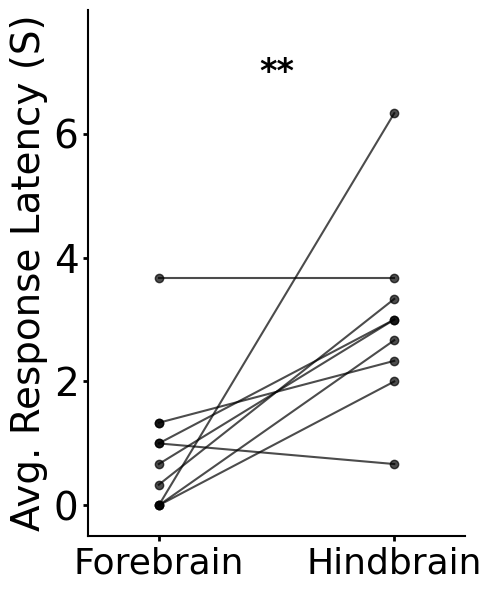

In [42]:
# Generate forebrain vs hindbrain plot
fig_fb_hb = plot_fb_hb_comparison(region_times_df)
plt.show()

# Uncomment to save
# fig_fb_hb.savefig(OUTPUT_FB_HB_PLOT, format="svg", dpi=300, bbox_inches="tight")

## Plot stimulus concentration latency 

In [ ]:
cad_order = ['cad_2.5mM','cad_250um','cad_25um']

plt.figure(figsize=(6,4))

for region in ['forebrain','hindbrain']:

    subset = latency_df[
        (latency_df['stimulus'].isin(cad_order)) &
        (latency_df['area']==region)
    ]

    means = subset.groupby('stimulus')['latency_sec'].mean()

    plt.plot(
        range(len(cad_order)),
        means[cad_order],
        marker='o',
        label=region
    )

plt.xticks(
    range(len(cad_order)),
    [STIMULUS_LABELS[s] for s in cad_order],
    rotation=45
)

plt.ylabel("Latency (s)")
plt.legend()

plt.show()

## 5. Area-Level Analysis

Analyze response latencies for specific brain areas, normalized to olfactory bulb.

In [10]:
def process_fish_by_area(fish, file_path, areas=BRAIN_AREAS):
    """Process a single fish across multiple brain areas.
    
    Args:
        fish: Fish ID string
        file_path: Path to HDF5 data file
        areas: List of brain areas to process
        
    Returns:
        list of dicts: [{'fish_id', 'area', 'onset_time'}, ...]
    """
    fish_df = pd.read_hdf(file_path, where='fish_id == fish')
    results = []
    
    for area in areas:
        area_df = fish_df[fish_df['area'] == area]
        stim_df = area_df[area_df['stimulus'].isin(KEY_STIMULI)]
        
        if not stim_df.empty:
            # Convert trace strings to arrays
            stim_df['trace'] = stim_df['trace_serialised'].apply(eval)
            
            # Average across all stimuli
            grand_avg = np.mean(np.stack(stim_df['trace'].values), axis=0)
            
            # Detect onset
            smoothed_trace, derivative, onset_time = detect_onset_smoothed_derivative(grand_avg)
            
            results.append({
                'fish_id': fish,
                'area': area,
                'onset_time': onset_time
            })
    
    return results

In [11]:
# Process all forebrain fish by area
print("Processing fish by brain area...")
onset_times_by_area = []

for fish in FOREBRAIN_FISH:
    results = process_fish_by_area(fish, FOREBRAIN_DATA_PATH)
    onset_times_by_area.extend(results)

# Convert to DataFrame
onset_times_df = pd.DataFrame(onset_times_by_area)

print(f"\nProcessed {onset_times_df['fish_id'].nunique()} fish across {onset_times_df['area'].nunique()} areas")
print(f"Total measurements: {len(onset_times_df)}")
print(f"Missing onset times: {onset_times_df['onset_time'].isna().sum()}")

display(onset_times_df.head())

Processing fish by brain area...

Processed 10 fish across 12 areas
Total measurements: 120
Missing onset times: 0


,fish_id,area,onset_time
0,230713_fb,olfactory_bulb,159
1,230713_fb,olfactory_epithelium,181
2,230713_fb,pallium,159
3,230713_fb,subpallium,159
4,230713_fb,posterior_tuberculum,159


In [12]:
# Filter for valid onset times
onset_df = onset_times_df[
    (onset_times_df['onset_time'] >= MIN_VALID_ONSET) & 
    (onset_times_df['onset_time'] <= MAX_VALID_ONSET)
]

print(f"Retained {len(onset_df)}/{len(onset_times_df)} measurements after filtering")
print(f"Filtered range: {MIN_VALID_ONSET} - {MAX_VALID_ONSET} frames")

Retained 118/120 measurements after filtering
Filtered range: 153 - 189 frames


### Normalize Latencies Relative to Olfactory Bulb

In [13]:
def normalize_latencies(data, reference_area=REFERENCE_AREA, 
                        frame_to_seconds=FRAME_TO_SECONDS):
    """Normalize onset times relative to reference area and convert to seconds.
    
    Args:
        data: DataFrame with columns ['fish_id', 'area', 'onset_time']
        reference_area: Area to normalize against (default from params)
        frame_to_seconds: Conversion factor (default from params)
        
    Returns:
        DataFrame with normalized onset times in seconds
    """
    normalized = data.copy()
    
    for fish_id in normalized['fish_id'].unique():
        fish_data = normalized[normalized['fish_id'] == fish_id]
        
        # Get reference area onset for this fish
        ref_onset = fish_data[fish_data['area'] == reference_area]['onset_time'].values
        
        if len(ref_onset) > 0:
            ref_onset = ref_onset[0]
            
            # Normalize: (onset - reference_onset) * frame_to_seconds
            normalized.loc[normalized['fish_id'] == fish_id, 'onset_time'] = (
                fish_data['onset_time'] - ref_onset
            ) * frame_to_seconds
    
    return normalized

In [14]:
# Normalize onset times
normalized_onset_times = normalize_latencies(onset_df)

# Convert area column to ordered categorical
normalized_onset_times['area'] = pd.Categorical(
    normalized_onset_times['area'], 
    categories=AREA_ORDER, 
    ordered=True
)

# Calculate summary statistics
mean_onset_times = normalized_onset_times.groupby('area')['onset_time'].mean().reindex(AREA_ORDER)
sem_onset_times = normalized_onset_times.groupby('area')['onset_time'].sem().reindex(AREA_ORDER)

print("\nNormalized latencies (seconds relative to OB):")
summary = pd.DataFrame({
    'area': [AREA_SHORTHAND_DICT[a] for a in AREA_ORDER],
    'mean': mean_onset_times.values,
    'sem': sem_onset_times.values
}).round(3)
display(summary)


Normalized latencies (seconds relative to OB):


,area,mean,sem
0,OE,2.200,0.631
1,OB,0.000,0.000
2,Pal,-0.067,0.044
3,SubP,0.033,0.033
4,POA,0.200,0.089
5,PTh,0.867,0.407
6,EmT,0.033,0.078
7,dHb,0.296,0.476
8,vHb,0.400,0.178
9,PT,3.400,0.813


### Statistical Testing (Wilcoxon Signed-Rank vs OB)

In [15]:
def test_areas_vs_reference(data, reference_area=REFERENCE_AREA, area_order=AREA_ORDER):
    """Perform Wilcoxon signed-rank test for each area vs reference.
    
    Uses paired test (fish-matched) comparing each area to reference area.
    
    Args:
        data: DataFrame with columns ['fish_id', 'area', 'onset_time']
        reference_area: Reference area for comparison (default from params)
        area_order: List of areas to test (default from params)
        
    Returns:
        DataFrame with columns ['area', 'p_value']
    """
    # Pivot to create fish-by-area matrix
    paired_df = data.pivot(index='fish_id', columns='area', values='onset_time')
    
    p_values = []
    area_names = []
    
    for area in area_order:
        if area != reference_area:
            if area in paired_df.columns and reference_area in paired_df.columns:
                # Get paired data (drop fish missing either measurement)
                paired = paired_df[[reference_area, area]].dropna()
                
                if len(paired) >= 2:
                    # Wilcoxon signed-rank test for paired samples
                    stat, p_val = wilcoxon(paired[reference_area], paired[area])
                else:
                    p_val = np.nan
            else:
                p_val = np.nan
            
            p_values.append(p_val)
            area_names.append(area)
    
    return pd.DataFrame({'area': area_names, 'p_value': p_values})

In [16]:
# Perform statistical tests
pval_df = test_areas_vs_reference(normalized_onset_times)

print(f"\nStatistical test: {STATISTICAL_TEST_AREAS.capitalize()} signed-rank test")
print(f"Reference area: {REFERENCE_AREA}")
print(f"Significant areas (p < 0.05): {sum(pval_df['p_value'] < 0.05)}")

display(pval_df)


Statistical test: Wilcoxon signed-rank test
Reference area: olfactory_bulb
Significant areas (p < 0.05): 4


,area,p_value
0,olfactory_epithelium,0.003906
1,pallium,0.500000
2,subpallium,1.000000
3,preoptic,0.125000
4,prethalamus,0.125000
5,eminentia_thalami,1.000000
6,dorsal_habenula,0.437500
7,ventral_habenula,0.093750
8,posterior_tuberculum,0.003906
9,rostral_hypothalamus,0.003906


### Create Summary Statistics Table

In [17]:
# Prepare data for boxplot (used in both plotting and stats table)
data_for_boxplot = [
    normalized_onset_times[normalized_onset_times['area'] == area]['onset_time'].values 
    for area in AREA_ORDER
]

# Create p-value dictionary for easy lookup
corrected_p_values_dict = dict(zip(pval_df['area'], pval_df['p_value']))

# Build results table
results = []
for i, area in enumerate(AREA_ORDER):
    data = data_for_boxplot[i]
    
    results.append({
        "area": AREA_SHORTHAND_DICT[area],
        "mean": np.mean(data),
        "std": np.std(data),
        "test": "Wilcoxon signed-rank",
        "p_value": corrected_p_values_dict.get(area, 1.0)
    })

results_df = pd.DataFrame(results)
results_df = results_df.set_index('area').loc[list(AREA_SHORTHAND_DICT.values())].reset_index()

display(results_df)

# Save results
results_df.to_csv(OUTPUT_AREA_CSV, index=False)
print(f"\nSaved area statistics to: {OUTPUT_AREA_CSV}")

,area,mean,std,test,p_value
0,OE,2.200000,1.892676,Wilcoxon signed-rank,0.003906
1,OB,0.000000,0.000000,Wilcoxon signed-rank,1.000000
2,Pal,-0.066667,0.133333,Wilcoxon signed-rank,0.500000
3,SubP,0.033333,0.100000,Wilcoxon signed-rank,1.000000
4,POA,0.200000,0.266667,Wilcoxon signed-rank,0.125000
5,PTh,0.866667,1.222020,Wilcoxon signed-rank,0.125000
6,EmT,0.033333,0.233333,Wilcoxon signed-rank,1.000000
7,dHb,0.296296,1.346641,Wilcoxon signed-rank,0.437500
8,vHb,0.400000,0.533333,Wilcoxon signed-rank,0.093750
9,PT,3.400000,2.439490,Wilcoxon signed-rank,0.003906



Saved area statistics to: /Volumes/LaCie/larval_HuC/imaging/7dpf_area_latency_stats.csv


### Plot Area Boxplot with Significance

In [18]:
def plot_area_latencies(data, area_order, p_values_dict):
    """Create boxplot of normalized latencies by brain area.
    
    Args:
        data: DataFrame with normalized onset times
        area_order: List of areas in plotting order
        p_values_dict: Dictionary mapping area names to p-values
        
    Returns:
        matplotlib.figure.Figure
    """
    # Color palette
    palette = {
        "OB": "#16327F", "OE": "#000000", "Pal": "#377DA3", "SubP": "#58C8FE",
        "PT": "#EF4066", "dHb": "#663200", "vHb": "#933264", "POA": "#8C8C00",
        "PTh": "#1E7F1D", "EmT": "#6CDA60", "HR": "#D9D900", "HI": "#EB7F25"
    }
    
    # Prepare data
    data_for_plot = [
        data[data['area'] == area]['onset_time'].values 
        for area in area_order
    ]
    
    # Create figure
    fig = plt.figure(figsize=(11, 6))
    
    # Create boxplot
    box_positions = np.arange(len(area_order))
    boxplot = plt.boxplot(
        data_for_plot, 
        vert=True,
        positions=box_positions, 
        widths=0.5, 
        patch_artist=True, 
        medianprops={'color': "black", 'linewidth': 4},
        whiskerprops={'color': "black", 'linewidth': 4},
        capprops={'linewidth': 0}
    )
    
    # Color boxes
    for i, area in enumerate(area_order):
        color = palette.get(AREA_SHORTHAND_DICT[area], "black")
        
        boxplot['boxes'][i].set_edgecolor(color)
        boxplot['boxes'][i].set_linewidth(3)
        boxplot['boxes'][i].set_facecolor("white")
        
        # Color whiskers and median
        for line in boxplot['whiskers'][i*2:(i+1)*2]:
            line.set_color(color)
            line.set_linewidth(3)
        
        for line in boxplot['medians'][i:i+1]:
            line.set_color(color)
            line.set_linewidth(3)
    
    # Overlay fish dots
    for i, area in enumerate(area_order):
        fish_data = data[data['area'] == area]['onset_time']
        plt.scatter(np.full_like(fish_data, i) + 0.4, fish_data, 
                   marker='o', s=30, alpha=0.7, color='black')
    
    # Add significance annotations
    for i, area in enumerate(area_order):
        if area == REFERENCE_AREA:
            continue
        
        p_val = p_values_dict.get(area, 1.0)
        
        if p_val < 0.001:
            significance = '***'
        elif p_val < 0.01:
            significance = '**'
        elif p_val < 0.05:
            significance = '*'
        else:
            significance = 'ns'
        
        plt.text(i, 8.5, significance, horizontalalignment='center', 
                fontsize=20, color='black', weight='bold')
    
    # Aesthetics
    plt.xlabel('', fontsize=18)
    plt.ylabel('Response Latency (S)', fontsize=33)
    
    ax = plt.gca()
    ax.set_xticks(np.arange(len(area_order)))
    ax.set_xticklabels([AREA_SHORTHAND_DICT[a] for a in area_order], 
                       fontsize=35, rotation=45)
    
    # Color x-axis labels
    for label, area in zip(ax.get_xticklabels(), area_order):
        label.set_color(palette.get(AREA_SHORTHAND_DICT[area], "black"))
    
    plt.yticks([0, 2, 4, 6, 8], fontsize=33)
    plt.ylim(-0.5, 8)
    
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(2)
    ax.spines['bottom'].set_linewidth(2)
    ax.tick_params(width=2)
    
    plt.tight_layout()
    
    return fig

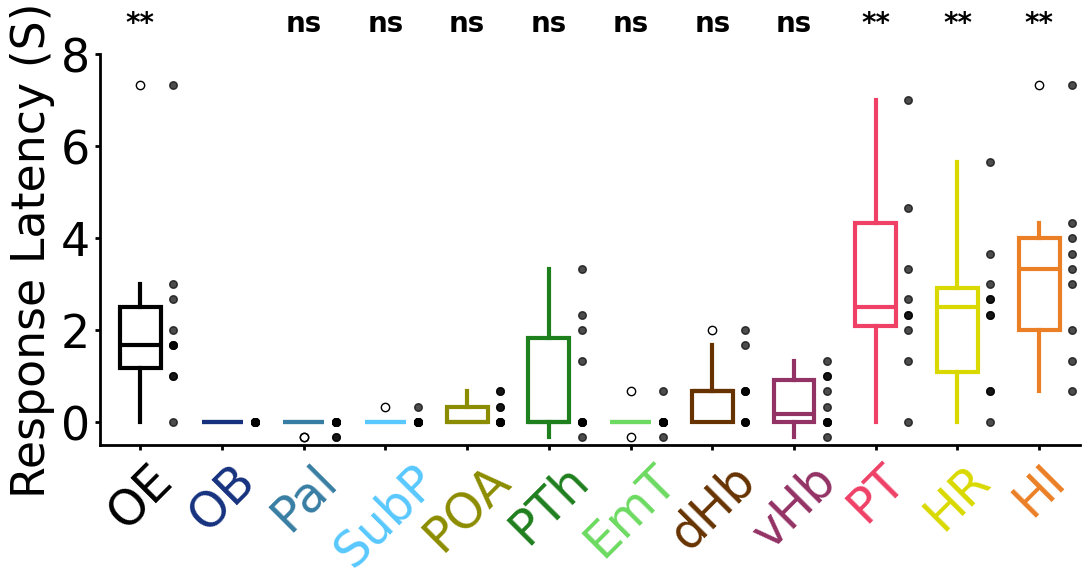

In [19]:
# Generate area boxplot
fig_areas = plot_area_latencies(normalized_onset_times, AREA_ORDER, corrected_p_values_dict)
plt.show()

# Uncomment to save
# fig_areas.savefig(OUTPUT_AREA_PLOT, format="svg", dpi=300, bbox_inches="tight")

## Analysis Complete

**Outputs:**
- Forebrain vs Hindbrain comparison saved to CSV
- Area-level statistics saved to CSV
- Paired comparison plot (FB vs HB) generated
- Area boxplot with significance annotations generated